# 03 — Statistiques Inférentielles



## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Tests statistiques
from scipy import stats
import pingouin as pg

# Modèle de régression
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

ALPHA = 0.05
print('Librairies chargées avec succès')


Librairies chargées avec succès


In [2]:

from pathlib import Path

WINDOWS_INF_OUTPUT_DIR = Path(r"C:\Users\Lenovo\Desktop\Brandwareprice_intelligence_project\data-analysis\outputs\inferential_statistics")

if WINDOWS_INF_OUTPUT_DIR.parent.exists():
    INF_OUTPUT_DIR = WINDOWS_INF_OUTPUT_DIR
else:
    INF_OUTPUT_DIR = Path("../outputs/inferential_statistics")

INF_TABLES_DIR = INF_OUTPUT_DIR / "tables"
INF_FIGURES_DIR = INF_OUTPUT_DIR / "figures"
INF_REPORTS_DIR = INF_OUTPUT_DIR / "reports"

for folder in [INF_TABLES_DIR, INF_FIGURES_DIR, INF_REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dossiers de sauvegarde prêts.")
print("Tables  :", INF_TABLES_DIR.resolve())
print("Figures :", INF_FIGURES_DIR.resolve())
print("Reports :", INF_REPORTS_DIR.resolve())


Dossiers de sauvegarde prêts.
Tables  : C:\Users\Lenovo\Documents\data-analysis\outputs\inferential_statistics\tables
Figures : C:\Users\Lenovo\Documents\data-analysis\outputs\inferential_statistics\figures
Reports : C:\Users\Lenovo\Documents\data-analysis\outputs\inferential_statistics\reports


## 2. Chargement et nettoyage des données

In [3]:
# 1. CHARGEMENT DU DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pq

# Chemins possibles du dataset
possible_paths = [
    Path("../data/processed/01_smartphones_cleaned.parquet"),
    Path("../data/processed/daily_prices_clean.parquet"),
    Path("data/processed/01_smartphones_cleaned.parquet"),
    Path("data/processed/daily_prices_clean.parquet")
]

# Chercher automatiquement le bon fichier
file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    print("Aucun fichier Parquet trouvé.")
    print("Dossier actuel :", Path.cwd())
    print("\nFichiers Parquet trouvés dans le projet :")

    found_files = list(Path("..").rglob("*.parquet")) + list(Path(".").rglob("*.parquet"))

    if len(found_files) == 0:
        print("Aucun fichier .parquet trouvé.")
    else:
        for file in found_files:
            print(file)

    raise FileNotFoundError("Place le fichier Parquet dans data/processed/ ou corrige son nom.")

print("Fichier utilisé :", file_path)

table = pq.read_table(file_path, use_pandas_metadata=False)
df = table.to_pandas(ignore_metadata=True)

for col in ["scraped_at", "date", "day"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("Chargement réussi.")
print("Dimensions :", df.shape)
print("Colonnes :", df.columns.tolist())

display(df.head())

Fichier utilisé : ..\data\processed\01_smartphones_cleaned.parquet
Chargement réussi.
Dimensions : (340, 14)
Colonnes : ['product_sk', 'name', 'brand', 'model', 'price', 'old_price', 'currency', 'discount', 'rating', 'reviews', 'url', 'source_site', 'scraped_at', 'scraped_date']


,product_sk,name,brand,model,price,old_price,currency,discount,rating,reviews,url,source_site,scraped_at,scraped_date
0,5b739bdbdb5c2920ef6d7656824ddb56,"Apple iPhone 15, 128 Go - Jaune (Reconditionné)",apple,iphone 15,430.57,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:02:19.748601+00:00,2026-04-26
1,87754977e4bfcb8854d9d95483a339a9,Apple iPhone 15 128Go - Bleu (Reconditionné),apple,iphone 15,429.15,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:09.359821+00:00,2026-04-26
2,4db3a5912f569e26e2a61c6ea4a2b980,Apple iPhone 15 128Go - Vert (Reconditionné),apple,iphone 15,434.11,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:09.975676+00:00,2026-04-26
3,c405652798dbf2d1712b252aaaef059f,Apple iPhone 15 256Go - Bleu (Reconditionné),apple,iphone 15,491.44,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:10.562642+00:00,2026-04-26
4,03467b57a1da616f2bc556fd77ac5808,"Apple iPhone 16, 128GB, Rose (Reconditionné)",apple,iphone 16,599.12,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:02:18.051862+00:00,2026-04-26


In [4]:
#  PRÉPARATION DES DOSSIERS OUTPUTS 

from pathlib import Path

OUTPUT_DIR = Path("../outputs")
INF_OUTPUT_DIR = OUTPUT_DIR / "inferential_statistics"

INF_TABLES_DIR = INF_OUTPUT_DIR / "tables"
INF_FIGURES_DIR = INF_OUTPUT_DIR / "figures"
INF_REPORTS_DIR = INF_OUTPUT_DIR / "reports"

for folder in [INF_TABLES_DIR, INF_FIGURES_DIR, INF_REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dossiers outputs inférentiels prêts.")
print("Chemin :", INF_OUTPUT_DIR.resolve())

Dossiers outputs inférentiels prêts.
Chemin : C:\Users\Lenovo\Documents\data-analysis\outputs\inferential_statistics


In [5]:
# Nettoyage pour les tests inférentiels
df_inf = df.copy()

if 'source_site' not in df_inf.columns:
    raise ValueError("La colonne 'source_site' est absente du dataset.")

df_inf['source_site'] = df_inf['source_site'].astype(str).str.strip().str.lower()


if 'currency' in df_inf.columns:
    df_inf['currency'] = (
        df_inf['currency']
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({'DHS': 'MAD', 'DH': 'MAD', 'MAD ': 'MAD', 'EUR ': 'EUR'})
    )
else:
    df_inf['currency'] = 'MAD'


df_inf['price'] = pd.to_numeric(df_inf['price'], errors='coerce')
df_inf = df_inf.dropna(subset=['price'])
df_inf = df_inf[df_inf['price'] > 0]

# Créer une colonne commune en MAD pour travailler sur les 3 plateformes
EUR_TO_MAD = 11

df_inf['price_mad'] = df_inf['price']
df_inf.loc[df_inf['currency'] == 'EUR', 'price_mad'] = (
    df_inf.loc[df_inf['currency'] == 'EUR', 'price'] * EUR_TO_MAD
)


if 'old_price' in df_inf.columns:
    df_inf['old_price'] = pd.to_numeric(df_inf['old_price'], errors='coerce')
    df_inf['old_price_mad'] = df_inf['old_price']
    df_inf.loc[df_inf['currency'] == 'EUR', 'old_price_mad'] = (
        df_inf.loc[df_inf['currency'] == 'EUR', 'old_price'] * EUR_TO_MAD
    )


q1 = df_inf['price_mad'].quantile(0.01)
q99 = df_inf['price_mad'].quantile(0.99)
df_inf = df_inf[(df_inf['price_mad'] >= q1) & (df_inf['price_mad'] <= q99)]


date_col = None
for c in ['scraped_at', 'date', 'day']:
    if c in df_inf.columns and df_inf[c].notna().sum() > 50:
        date_col = c
        df_inf['days_since_start'] = (df_inf[c] - df_inf[c].min()).dt.days
        break

df_stats = df_inf.copy()

print('Dataset nettoyé :', df_inf.shape)
print('Variable date utilisée :', date_col)
print('\nDistribution par plateforme après conversion en MAD :')
display(df_inf['source_site'].value_counts())
display(df_inf['price_mad'].describe().round(2))


Dataset nettoyé : (332, 17)
Variable date utilisée : scraped_at

Distribution par plateforme après conversion en MAD :


source_site
jumia_ma         266
electroplanet     48
amazon_fr         18
Name: count, dtype: int64

count      332.00
mean      5104.85
std       4817.73
min        152.02
25%       1649.00
50%       2994.50
75%       6602.49
max      19230.00
Name: price_mad, dtype: float64

In [6]:
# Vérification des colonnes disponibles
cols_to_check = ['source_site', 'brand', 'category', 'rating', 'reviews', 'old_price']
available = {col: col in df_inf.columns for col in cols_to_check}

for col, exists in available.items():
    status = 'disponible' if exists else 'absente'
    print(f'  {col:15s} : {status}')

# Identifier la variable plateforme
platform_col = 'source_site'
platform_counts = df_inf[platform_col].value_counts()

# Sélectionner explicitement les 3 plateformes du projet si elles existent
preferred_keywords = ['jumia', 'electro', 'amazon']
top3 = []
for key in preferred_keywords:
    matches = [p for p in platform_counts.index if key in str(p).lower()]
    if matches:
        top3.append(matches[0])

# Si une plateforme manque, compléter par les plateformes les plus fréquentes
for p in platform_counts.index:
    if p not in top3 and len(top3) < 3:
        top3.append(p)

top2 = top3[:2]

print(f'\nPlateforme 1 : {top2[0]}')
print(f'Plateforme 2 : {top2[1]}')
print(f'Plateformes retenues pour les tests à 3 groupes : {top3}')
print(f'\nDistribution par plateforme :')
display(platform_counts)


  source_site     : disponible
  brand           : disponible
  category        : absente
  rating          : disponible
  reviews         : disponible
  old_price       : disponible

Plateforme 1 : jumia_ma
Plateforme 2 : electroplanet
Plateformes retenues pour les tests à 3 groupes : ['jumia_ma', 'electroplanet', 'amazon_fr']

Distribution par plateforme :


source_site
jumia_ma         266
electroplanet     48
amazon_fr         18
Name: count, dtype: int64

## 3. Exploration visuelle préliminaire

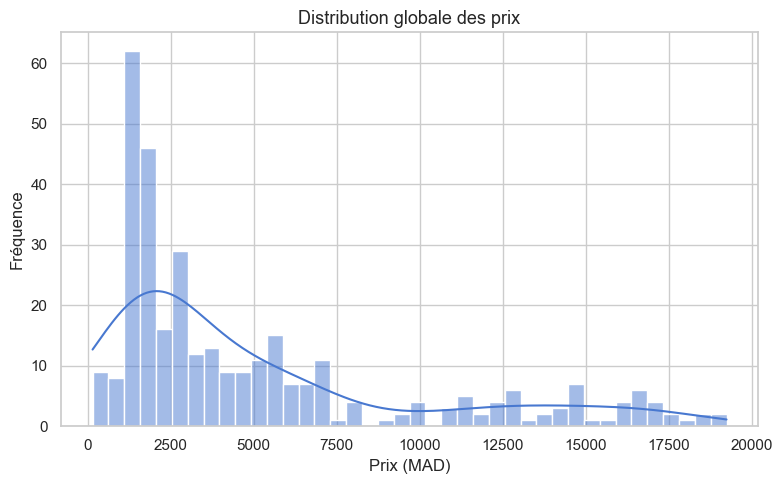

Figure sauvegardée : global_price_distribution.png


In [7]:
# Figure 1 : Histogramme de la distribution globale des prix

plt.figure(figsize=(8, 5))

sns.histplot(df_inf['price_mad'].dropna(), bins=40, kde=True)

plt.title('Distribution globale des prix', fontsize=13)
plt.xlabel('Prix (MAD)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.savefig(INF_FIGURES_DIR / "global_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : global_price_distribution.png")


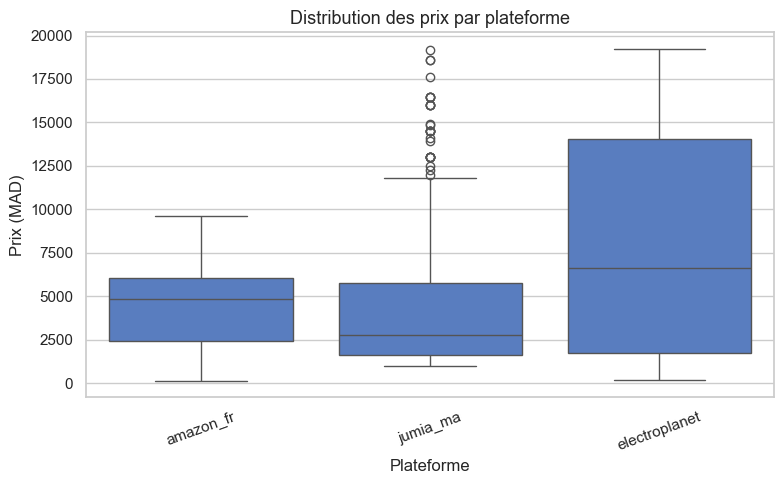

Figure sauvegardée : price_by_platform_boxplot.png


In [8]:
# Figure 2 : Boxplot des prix par plateforme

df_top = df_inf[df_inf[platform_col].isin(top3)]

plt.figure(figsize=(8, 5))

sns.boxplot(data=df_top, x=platform_col, y='price_mad')

plt.title('Distribution des prix par plateforme', fontsize=13)
plt.xlabel('Plateforme')
plt.ylabel('Prix (MAD)')

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(INF_FIGURES_DIR / "price_by_platform_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : price_by_platform_boxplot.png")


## 4. Vérification des préalables

Avant tout test, on vérifie deux conditions :
1. **Normalité** (Shapiro-Wilk) : les données suivent-elles une loi normale ?
2. **Homoscédasticité** (Levene) : les variances des groupes sont-elles égales ?

In [9]:
# Extraire les prix des deux plateformes principales

plateforme_1 = top2[0]
plateforme_2 = top2[1]

group1 = df_inf[df_inf[platform_col] == plateforme_1]['price_mad'].dropna()
group2 = df_inf[df_inf[platform_col] == plateforme_2]['price_mad'].dropna()

print("Plateforme 1 :", plateforme_1)
print("Nombre d'observations :", len(group1))

print("\nPlateforme 2 :", plateforme_2)
print("Nombre d'observations :", len(group2))

print("\nPlateformes disponibles pour l'analyse à 3 groupes :")
print(df_inf[df_inf[platform_col].isin(top3)][platform_col].value_counts())


Plateforme 1 : jumia_ma
Nombre d'observations : 266

Plateforme 2 : electroplanet
Nombre d'observations : 48

Plateformes disponibles pour l'analyse à 3 groupes :
source_site
jumia_ma         266
electroplanet     48
amazon_fr         18
Name: count, dtype: int64


In [10]:
# Test de normalité avec Pingouin : Shapiro-Wilk
# On limite à 500 observations pour garder un test stable et simple.

normality_results = []
samples = {}

for platform in top3:
    values = df_inf[df_inf[platform_col] == platform]['price_mad'].dropna()
    if len(values) >= 3:
        sample = values.sample(min(len(values), 500), random_state=42)
        samples[platform] = sample
        res = pg.normality(sample, method='shapiro')
        res['Plateforme'] = platform
        normality_results.append(res)

normality_table = pd.concat(normality_results, ignore_index=True)

# Variables conservées pour les cellules suivantes
sample1 = samples[top2[0]]
sample2 = samples[top2[1]]
normality_1 = normality_table[normality_table['Plateforme'] == top2[0]]
normality_2 = normality_table[normality_table['Plateforme'] == top2[1]]

stat_sw1 = normality_1['W'].iloc[0]
p_sw1 = normality_1['pval'].iloc[0]
stat_sw2 = normality_2['W'].iloc[0]
p_sw2 = normality_2['pval'].iloc[0]

print('=== Test de normalité : Shapiro-Wilk avec Pingouin ===')

for _, row in normality_table.iterrows():
    print(f"{row['Plateforme']} : W = {row['W']:.4f}, p-value = {row['pval']:.4f}")
    if row['pval'] < ALPHA:
        print('Conclusion : les prix ne suivent pas une loi normale.')
    else:
        print('Conclusion : les prix peuvent être considérés comme normaux.')
    print()

display(normality_table)


# Sauvegarde du tableau de normalité
normality_table.to_csv(INF_TABLES_DIR / "normality_shapiro_results.csv", index=False)
print("Table sauvegardée : normality_shapiro_results.csv")


=== Test de normalité : Shapiro-Wilk avec Pingouin ===
jumia_ma : W = 0.7599, p-value = 0.0000
Conclusion : les prix ne suivent pas une loi normale.

electroplanet : W = 0.8555, p-value = 0.0000
Conclusion : les prix ne suivent pas une loi normale.

amazon_fr : W = 0.9185, p-value = 0.1214
Conclusion : les prix peuvent être considérés comme normaux.



,W,pval,normal,Plateforme
0,0.759853,2.037711e-19,False,jumia_ma
1,0.855543,3.061364e-05,False,electroplanet
2,0.918451,1.213582e-01,True,amazon_fr


Table sauvegardée : normality_shapiro_results.csv


In [11]:
# Test d'homoscédasticité avec Pingouin : Levene
# Objectif : vérifier si les deux plateformes ont des variances similaires.

df_two_platforms = df_inf[df_inf[platform_col].isin(top3)][[platform_col, 'price_mad']].dropna()

levene_groups = [
    df_two_platforms[df_two_platforms[platform_col] == platform]['price_mad']
    for platform in top3
    if len(df_two_platforms[df_two_platforms[platform_col] == platform]) > 1
]

stat_lev, p_lev = stats.levene(*levene_groups)

levene_result = pd.DataFrame({
    'W': [stat_lev],
    'pval': [p_lev],
    'equal_var': [p_lev >= ALPHA]
})

print("=== Test d'homoscédasticité : Levene avec Pingouin ===")
print(f'Statistique = {stat_lev:.4f}')
print(f'p-value = {p_lev:.4f}')

if p_lev < ALPHA:
    print('Conclusion : les variances sont significativement différentes.')
else:
    print('Conclusion : les variances peuvent être considérées comme égales.')

display(levene_result)


# Sauvegarde du test de Levene
levene_result.to_csv(INF_TABLES_DIR / "levene_homoscedasticity_result.csv", index=False)
print("Table sauvegardée : levene_homoscedasticity_result.csv")


=== Test d'homoscédasticité : Levene avec Pingouin ===
Statistique = 13.8644
p-value = 0.0000
Conclusion : les variances sont significativement différentes.


,W,pval,equal_var
0,13.864358,0.000002,False


Table sauvegardée : levene_homoscedasticity_result.csv


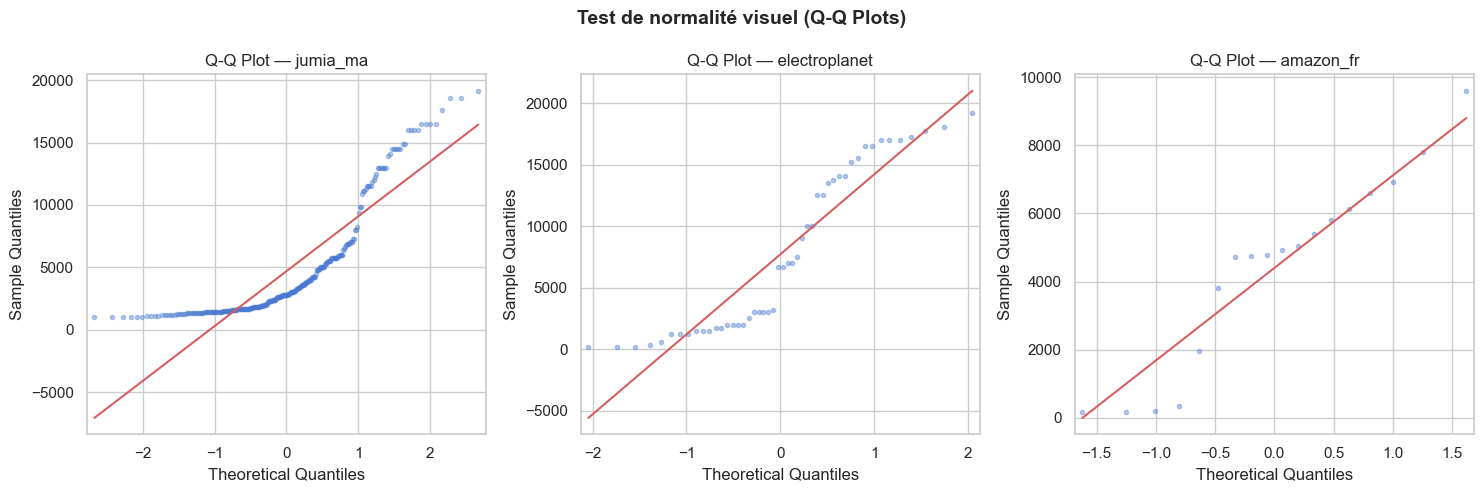

Figure sauvegardée : qqplots_normality.png


In [12]:
# Q-Q plots 
fig, axes = plt.subplots(1, len(top3), figsize=(5 * len(top3), 5))

if len(top3) == 1:
    axes = [axes]

for ax, platform in zip(axes, top3):
    values = samples.get(platform)
    if values is not None and len(values) >= 3:
        sm.qqplot(values, line='s', ax=ax, alpha=0.4, markersize=3)
        ax.set_title(f'Q-Q Plot — {platform}', fontsize=12)

plt.suptitle('Test de normalité visuel (Q-Q Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(INF_FIGURES_DIR / "qqplots_normality.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : qqplots_normality.png")


## 5. Comparaison de deux plateformes : t-test ou Mann-Whitney U

**H₀ :** Les prix médians/moyens des deux plateformes sont égaux.  
**H₁ :** Les prix sont différents entre les deux plateformes.  
**Seuil :** α = 0.05

In [13]:
# Test de Mann-Whitney avec Pingouin : comparaison des prix entre deux plateformes

from scipy.stats import mannwhitneyu
from itertools import combinations

mw_rows = []

for p1, p2 in combinations(top3, 2):
    g1 = df_inf[df_inf[platform_col] == p1]['price_mad'].dropna()
    g2 = df_inf[df_inf[platform_col] == p2]['price_mad'].dropna()
    
    if len(g1) > 0 and len(g2) > 0:
        stat, p_value = mannwhitneyu(g1, g2, alternative='two-sided')
        mw_rows.append({
            'Plateforme 1': p1,
            'Plateforme 2': p2,
            'n1': len(g1),
            'n2': len(g2),
            'U-val': stat,
            'p-val': p_value,
            'Significatif à 5%': p_value < ALPHA
        })

mw_result = pd.DataFrame(mw_rows)

# Variables conservées pour la suite du notebook : première comparaison
stat_mw = mw_result['U-val'].iloc[0]
p_mw = mw_result['p-val'].iloc[0]

print('=== Test de Mann-Whitney avec Pingouin ===')
print(f'Comparaison principale : {top2[0]} vs {top2[1]}')
print(f'Statistique U = {stat_mw:.4f}')
print(f'p-value = {p_mw:.4f}')

if p_mw < ALPHA:
    print('Conclusion : il existe une différence significative de prix entre les deux plateformes.')
else:
    print("Conclusion : aucune différence significative de prix n'a été détectée entre les deux plateformes.")

print('\nComparaisons deux à deux sur les 3 plateformes :')
display(mw_result)


# Sauvegarde du test Mann-Whitney
mw_result.to_csv(INF_TABLES_DIR / "ttest_mannwhitney_results.csv", index=False)
print("Table sauvegardée : ttest_mannwhitney_results.csv")


=== Test de Mann-Whitney avec Pingouin ===
Comparaison principale : jumia_ma vs electroplanet
Statistique U = 5079.5000
p-value = 0.0243
Conclusion : il existe une différence significative de prix entre les deux plateformes.

Comparaisons deux à deux sur les 3 plateformes :


,Plateforme 1,Plateforme 2,n1,n2,U-val,p-val,Significatif à 5%
0,jumia_ma,electroplanet,266,48,5079.5,0.024287,True
1,jumia_ma,amazon_fr,266,18,2154.0,0.477534,False
2,electroplanet,amazon_fr,48,18,533.0,0.147759,False


Table sauvegardée : ttest_mannwhitney_results.csv


In [14]:
# Statistiques descriptives
desc = (
    df_inf[df_inf[platform_col].isin(top3)]
    .groupby(platform_col)['price_mad']
    .agg(n='count', Moyenne='mean', Médiane='median', **{'Écart-type': 'std'}, Min='min', Max='max')
    .reset_index()
    .rename(columns={platform_col: 'Plateforme'})
    .round(2)
)

print(' STATISTIQUES DESCRIPTIVES PAR PLATEFORME ')
display(desc)


# Sauvegarde des statistiques descriptives utilisées dans l'analyse inférentielle
desc.to_csv(INF_TABLES_DIR / "platform_descriptive_summary.csv", index=False)
print("Table sauvegardée : platform_descriptive_summary.csv")


 STATISTIQUES DESCRIPTIVES PAR PLATEFORME 


,Plateforme,n,Moyenne,Médiane,Écart-type,Min,Max
0,amazon_fr,18,4397.88,4851.6,2799.71,152.02,9608.17
1,electroplanet,48,7705.69,6639.0,6571.38,169.00,19230.00
2,jumia_ma,266,4683.36,2790.0,4403.63,989.00,19152.00


Table sauvegardée : platform_descriptive_summary.csv


In [15]:
# TAILLE D'EFFET POUR MANN-WHITNEY


# Nombre d'observations dans chaque groupe
n1 = len(group1)
n2 = len(group2)

# Moyenne théorique de U sous H0
mean_u = n1 * n2 / 2

# Écart-type théorique de U sous H0
std_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

# Conversion de U en z-score
z_score = (stat_mw - mean_u) / std_u
# Taille d'effet r
r_effect = abs(z_score) / np.sqrt(n1 + n2)

print("=== Taille d'effet Mann-Whitney ===")
print(f"n1 = {n1}")
print(f"n2 = {n2}")
print(f"z-score = {z_score:.4f}")
print(f"r = {r_effect:.4f}")

# Interprétation simple de r
if r_effect < 0.10:
    interpretation_r = "effet très faible"
elif r_effect < 0.30:
    interpretation_r = "effet faible"
elif r_effect < 0.50:
    interpretation_r = "effet moyen"
else:
    interpretation_r = "effet fort"

print(f"Interprétation : {interpretation_r}")


# Sauvegarde de la taille d'effet Mann-Whitney
mannwhitney_effect_size = pd.DataFrame({
    "test": ["Mann-Whitney"],
    "platform_1": [plateforme_1],
    "platform_2": [plateforme_2],
    "n1": [n1],
    "n2": [n2],
    "z_score": [z_score],
    "r_effect": [r_effect],
    "interpretation": [interpretation_r]
})
mannwhitney_effect_size.to_csv(INF_TABLES_DIR / "mannwhitney_effect_size.csv", index=False)
print("Table sauvegardée : mannwhitney_effect_size.csv")


=== Taille d'effet Mann-Whitney ===
n1 = 266
n2 = 48
z-score = -2.2533
r = 0.1272
Interprétation : effet faible
Table sauvegardée : mannwhitney_effect_size.csv


## 6. ANOVA et Kruskal-Wallis (≥ 3 groupes)

**H₀ :** Les prix sont identiques dans tous les groupes.  
**H₁ :** Au moins un groupe présente des prix différents.  
**Seuil :** α = 0.05

In [16]:

# ANOVA / KRUSKAL-WALLIS : CHOIX DES GROUPES


ALPHA = 0.05

# Choisir la colonne de comparaison.

group_col = 'source_site'  
price_col = 'price_mad'

# Vérifier que les colonnes existent
if group_col not in df_inf.columns:
    raise ValueError(f"La colonne {group_col} n'existe pas dans le dataset.")

if price_col not in df_inf.columns:
    raise ValueError("La colonne 'price_mad' n'existe pas dans le dataset.")

# Garder uniquement les lignes utiles sur les 3 plateformes
if group_col == 'source_site':
    df_groups = df_inf[df_inf[group_col].isin(top3)][[group_col, price_col]].dropna().copy()
else:
    df_groups = df_inf[[group_col, price_col]].dropna().copy()

# Garder seulement les groupes avec au moins 5 observations
group_counts = df_groups[group_col].value_counts()
valid_groups = group_counts[group_counts >= 5].index

df_groups = df_groups[df_groups[group_col].isin(valid_groups)]

print(f'Colonne utilisée pour les groupes : {group_col}')
print(f'Nombre de groupes valides : {df_groups[group_col].nunique()}')

display(df_groups[group_col].value_counts().to_frame("Nombre d'observations"))


Colonne utilisée pour les groupes : source_site
Nombre de groupes valides : 3


,Nombre d'observations
source_site,
jumia_ma,266
electroplanet,48
amazon_fr,18


In [17]:

# PRÉPARATION DES GROUPES


groups = [
    df_groups[df_groups[group_col] == group][price_col]
    for group in df_groups[group_col].unique()
]

if len(groups) < 3:
    raise ValueError("Il faut au moins 3 groupes valides pour faire ANOVA ou Kruskal-Wallis.")

print(f"Nombre de groupes utilisés : {len(groups)}")


Nombre de groupes utilisés : 3


In [18]:

# TEST ANOVA avec Pingouin


stat_anova, p_anova = stats.f_oneway(*groups)

anova_result = pd.DataFrame({
    'Source': [group_col],
    'F': [stat_anova],
    'p-unc': [p_anova]
})

print('Résultat du test ANOVA avec Pingouin')
print(f'Statistique F : {stat_anova:.4f}')
print(f'p-value       : {p_anova:.4f}')

if p_anova < ALPHA:
    print('Décision : Rejet de H0')
    print('Conclusion : au moins un groupe a un prix moyen significativement différent.')
else:
    print('Décision : Non-rejet de H0')
    print('Conclusion : aucune différence significative des prix moyens entre les groupes.')

display(anova_result)


# Sauvegarde du test ANOVA
anova_result.to_csv(INF_TABLES_DIR / "anova_result.csv", index=False)
print("Table sauvegardée : anova_result.csv")


Résultat du test ANOVA avec Pingouin
Statistique F : 8.5822
p-value       : 0.0002
Décision : Rejet de H0
Conclusion : au moins un groupe a un prix moyen significativement différent.


,Source,F,p-unc
0,source_site,8.582174,0.000233


Table sauvegardée : anova_result.csv


In [19]:

# TEST DE KRUSKAL-WALLIS avec Pingouin


stat_kw, p_kw = stats.kruskal(*groups)

kruskal_result = pd.DataFrame({
    'Source': [group_col],
    'H': [stat_kw],
    'p-unc': [p_kw]
})

print('Résultat du test de Kruskal-Wallis avec Pingouin')
print(f'Statistique H : {stat_kw:.4f}')
print(f'p-value       : {p_kw:.4f}')

if p_kw < ALPHA:
    print('Décision : Rejet de H0')
    print('Conclusion : les distributions de prix diffèrent entre au moins deux groupes.')
else:
    print('Décision : Non-rejet de H0')
    print('Conclusion : aucune différence significative détectée entre les groupes.')

display(kruskal_result)


# Sauvegarde du test Kruskal-Wallis
kruskal_result.to_csv(INF_TABLES_DIR / "kruskal_wallis_result.csv", index=False)
print("Table sauvegardée : kruskal_wallis_result.csv")


Résultat du test de Kruskal-Wallis avec Pingouin
Statistique H : 5.5575
p-value       : 0.0621
Décision : Non-rejet de H0
Conclusion : aucune différence significative détectée entre les groupes.


,Source,H,p-unc
0,source_site,5.557477,0.062117


Table sauvegardée : kruskal_wallis_result.csv


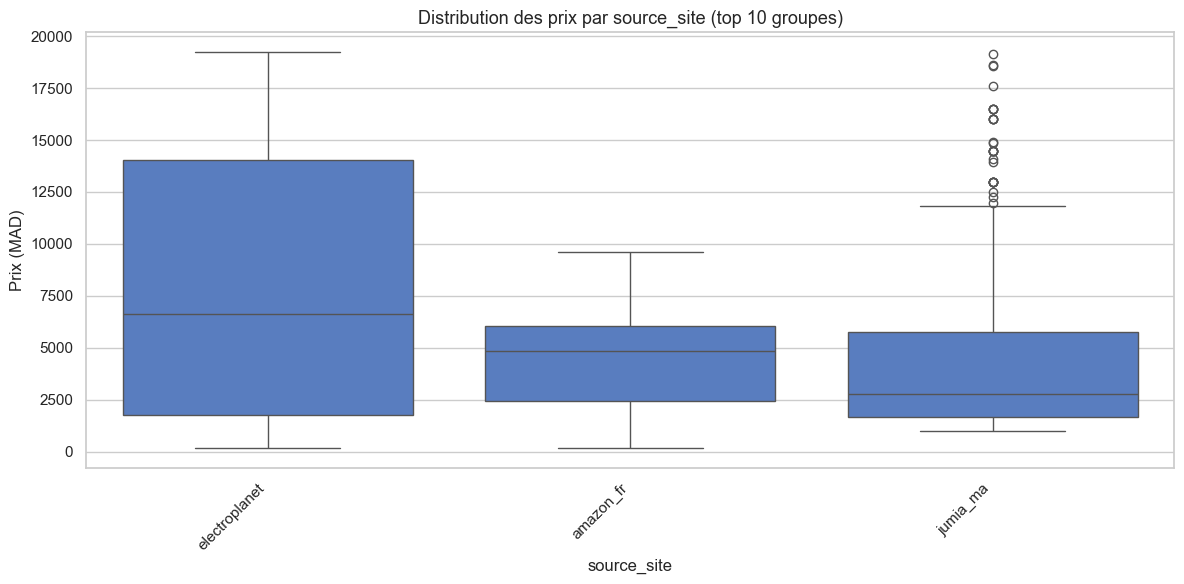

Figure sauvegardée : anova_kruskal_group_boxplot.png


In [20]:
# Boxplot par groupe 

if group_col is not None and len(valid_groups) >= 3:
    
    plt.figure(figsize=(12, 6))

    order = (
        df_groups.groupby(group_col)[price_col]
        .median()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=df_groups,
        x=group_col,
        y=price_col,
        order=order[:10]
    )

    plt.title(f"Distribution des prix par {group_col} (top 10 groupes)", fontsize=13)
    plt.xlabel(group_col)
    plt.ylabel("Prix (MAD)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(INF_FIGURES_DIR / "anova_kruskal_group_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : anova_kruskal_group_boxplot.png")

else:
    print("Graphique non affiché : il faut au moins 3 groupes valides pour ANOVA / Kruskal-Wallis.")


## 7. Régression linéaire multiple

**Modèle :** `price ~ rating + reviews + days_since_start + C(source_site)`  
(les variables sont incluses selon leur disponibilité dans le dataset)

**H₀ :** Le coefficient de la variable = 0 (pas d'effet sur le prix).  
**H₁ :** Le coefficient ≠ 0 (la variable influence le prix).

In [21]:

# PRÉPARATION DES DONNÉES POUR LA RÉGRESSION


import statsmodels.formula.api as smf

# On utilise le dataset inférentiel déjà nettoyé
df_reg = df_inf.copy()

# Vérifier que la variable cible existe
if "price_mad" not in df_reg.columns:
    raise ValueError("La colonne 'price_mad' est absente du dataset.")

# Garder uniquement les prix valides
df_reg = df_reg.dropna(subset=["price_mad"])
df_reg = df_reg[df_reg["price_mad"] > 0]

print("Données préparées pour la régression.")
print(f"Nombre de lignes utilisées : {len(df_reg)}")
print("Plateformes utilisées dans la régression :")
print(df_reg['source_site'].value_counts())
display(df_reg.head())


Données préparées pour la régression.
Nombre de lignes utilisées : 332
Plateformes utilisées dans la régression :
source_site
jumia_ma         266
electroplanet     48
amazon_fr         18
Name: count, dtype: int64


,product_sk,name,brand,model,price,old_price,currency,discount,rating,reviews,url,source_site,scraped_at,scraped_date,price_mad,old_price_mad,days_since_start
0,5b739bdbdb5c2920ef6d7656824ddb56,"Apple iPhone 15, 128 Go - Jaune (Reconditionné)",apple,iphone 15,430.57,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:02:19.748601+00:00,2026-04-26,4736.27,NaN,0
1,87754977e4bfcb8854d9d95483a339a9,Apple iPhone 15 128Go - Bleu (Reconditionné),apple,iphone 15,429.15,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:09.359821+00:00,2026-04-26,4720.65,NaN,0
2,4db3a5912f569e26e2a61c6ea4a2b980,Apple iPhone 15 128Go - Vert (Reconditionné),apple,iphone 15,434.11,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:09.975676+00:00,2026-04-26,4775.21,NaN,0
3,c405652798dbf2d1712b252aaaef059f,Apple iPhone 15 256Go - Bleu (Reconditionné),apple,iphone 15,491.44,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:03:10.562642+00:00,2026-04-26,5405.84,NaN,0
4,03467b57a1da616f2bc556fd77ac5808,"Apple iPhone 16, 128GB, Rose (Reconditionné)",apple,iphone 16,599.12,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:02:18.051862+00:00,2026-04-26,6590.32,NaN,0


In [22]:

#  CHOIX DES VARIABLES EXPLICATIVES


variables = []

# Variables numériques disponibles
for col in ["rating", "reviews", "old_price_mad"]:
    if col in df_reg.columns and df_reg[col].notna().sum() > 30:
        variables.append(col)

# Variable temporelle si disponible
if "scraped_at" in df_reg.columns:
    df_reg["scraped_at"] = pd.to_datetime(df_reg["scraped_at"], errors="coerce")
    df_reg["days_since_start"] = (
        df_reg["scraped_at"] - df_reg["scraped_at"].min()
    ).dt.days

    if df_reg["days_since_start"].nunique() > 1:
        variables.append("days_since_start")

# Variable catégorielle : plateforme
if "source_site" in df_reg.columns and df_reg["source_site"].nunique() >= 2:
    variables.append("C(source_site)")

print("Variables explicatives retenues :")
print(variables)

if len(variables) == 0:
    raise ValueError("Aucune variable explicative valide n'a été trouvée.")


Variables explicatives retenues :
['rating', 'reviews', 'old_price_mad', 'C(source_site)']


In [23]:

# FORMULATION DU MODÈLE

formula = "price_mad ~ " + " + ".join(variables)

print("Modèle de régression linéaire multiple :")
print(formula)


Modèle de régression linéaire multiple :
price_mad ~ rating + reviews + old_price_mad + C(source_site)


In [24]:

#  ESTIMATION DU MODÈLE OLS


model = smf.ols(formula=formula, data=df_reg).fit()

print("=== Résultats globaux du modèle ===")
print(f"R²                 : {model.rsquared:.4f}")
print(f"R² ajusté          : {model.rsquared_adj:.4f}")
print(f"p-value globale    : {model.f_pvalue:.4g}")
print(f"Nombre d'observations : {int(model.nobs)}")


=== Résultats globaux du modèle ===
R²                 : 0.9757
R² ajusté          : 0.9742
p-value globale    : 9.891e-39
Nombre d'observations : 52


In [25]:

# TABLEAU SIMPLE DES COEFFICIENTS
coef_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "p-value": model.pvalues.values
})

coef_table["Significatif à 5%"] = coef_table["p-value"] < 0.05

display(coef_table.round(4))


# Sauvegarde du tableau des coefficients de régression
coef_table.to_csv(INF_TABLES_DIR / "regression_results.csv", index=False)
with open(INF_TABLES_DIR / "regression_summary.txt", "w", encoding="utf-8") as f:
    f.write(model.summary().as_text())
print("Tables sauvegardées : regression_results.csv et regression_summary.txt")


,Variable,Coefficient,p-value,Significatif à 5%
0,Intercept,44.6314,0.6600,False
1,C(source_site)[T.electroplanet],0.0000,0.6589,False
2,C(source_site)[T.jumia_ma],44.6314,0.6600,False
3,rating,57.8121,0.1901,False
4,reviews,-1.2479,0.3644,False
5,old_price_mad,0.6708,0.0000,True


Tables sauvegardées : regression_results.csv et regression_summary.txt


In [26]:

#  INTERPRÉTATION AUTOMATIQUE DU MODÈLE


if model.f_pvalue < ALPHA:
    print("Le modèle est globalement significatif.")
    print("Au moins une variable explicative influence significativement le prix.")
else:
    print("Le modèle n'est pas globalement significatif.")
    print("Les variables disponibles n'expliquent pas clairement le prix.")

print(f"\nLe modèle explique environ {model.rsquared * 100:.2f}% de la variation des prix.")


Le modèle est globalement significatif.
Au moins une variable explicative influence significativement le prix.

Le modèle explique environ 97.57% de la variation des prix.


In [27]:

#  TABLEAU DES COEFFICIENTS


coef_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "p-value": model.pvalues.values
})

coef_table["Significatif à 5%"] = coef_table["p-value"] < 0.05

display(coef_table.round(4))


,Variable,Coefficient,p-value,Significatif à 5%
0,Intercept,44.6314,0.6600,False
1,C(source_site)[T.electroplanet],0.0000,0.6589,False
2,C(source_site)[T.jumia_ma],44.6314,0.6600,False
3,rating,57.8121,0.1901,False
4,reviews,-1.2479,0.3644,False
5,old_price_mad,0.6708,0.0000,True


##  Vérification de la multicolinéarité avec le VIF

Le **VIF (Variance Inflation Factor)** permet de vérifier si certaines variables explicatives sont trop corrélées entre elles.

Règle simple d'interprétation :

- **VIF < 5** : multicolinéarité acceptable ;
- **5 ≤ VIF < 10** : multicolinéarité à surveiller ;
- **VIF ≥ 10** : multicolinéarité forte.

Cette étape est importante ici, car `old_price` peut être fortement liée à `price`.


In [28]:

# CALCUL DU VIF POUR LES VARIABLES DU MODÈLE


# Matrice utilisée par statsmodels après transformation de la formule
X_vif = pd.DataFrame(model.model.exog, columns=model.model.exog_names)

# On retire l'intercept car il n'est pas interprété comme une variable explicative
X_vif_no_intercept = X_vif.drop(columns=['Intercept'], errors='ignore')

vif_rows = []
for i, col in enumerate(X_vif_no_intercept.columns):
    vif_value = variance_inflation_factor(X_vif_no_intercept.values, i)
    vif_rows.append({
        'Variable': col,
        'VIF': vif_value
    })

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)

def interpret_vif(v):
    if v < 5:
        return 'Acceptable'
    elif v < 10:
        return 'À surveiller'
    else:
        return 'Multicolinéarité forte'

vif_df['Interprétation'] = vif_df['VIF'].apply(interpret_vif)

display(vif_df.round(3))

if 'old_price' in vif_df['Variable'].values:
    old_price_vif = vif_df.loc[vif_df['Variable'] == 'old_price', 'VIF'].iloc[0]
    print(f"VIF de old_price : {old_price_vif:.3f}")
    if old_price_vif >= 10:
        print("Conclusion : old_price présente une multicolinéarité forte. C'est attendu car old_price est naturellement lié au prix actuel.")
    elif old_price_vif >= 5:
        print("Conclusion : old_price présente une multicolinéarité à surveiller.")
    else:
        print("Conclusion : old_price ne présente pas de problème majeur de multicolinéarité.")
else:
    print("old_price n'est pas présent dans le modèle ; le VIF spécifique à old_price ne peut pas être calculé.")


# Sauvegarde du VIF
vif_df.to_csv(INF_TABLES_DIR / "vif_multicollinearity_results.csv", index=False)
print("Table sauvegardée : vif_multicollinearity_results.csv")


,Variable,VIF,Interprétation
1,C(source_site)[T.jumia_ma],27.201,Multicolinéarité forte
4,old_price_mad,1.048,Acceptable
3,reviews,1.048,Acceptable
2,rating,1.001,Acceptable
0,C(source_site)[T.electroplanet],NaN,Multicolinéarité forte


old_price n'est pas présent dans le modèle ; le VIF spécifique à old_price ne peut pas être calculé.
Table sauvegardée : vif_multicollinearity_results.csv


In [29]:

# EXEMPLE DE PRÉDICTION


# On prend un produit existant comme exemple
exemple = df_reg.iloc[[0]].copy()

prediction = model.predict(exemple)

print("Exemple de prédiction sur une ligne du dataset :")
print(f"Prix réel      : {exemple['price_mad'].iloc[0]:.2f}")
print(f"Prix prédit    : {prediction.iloc[0]:.2f}")

display(exemple)


Exemple de prédiction sur une ligne du dataset :
Prix réel      : 4736.27
Prix prédit    : nan


,product_sk,name,brand,model,price,old_price,currency,discount,rating,reviews,url,source_site,scraped_at,scraped_date,price_mad,old_price_mad,days_since_start
0,5b739bdbdb5c2920ef6d7656824ddb56,"Apple iPhone 15, 128 Go - Jaune (Reconditionné)",apple,iphone 15,430.57,NaN,EUR,NaN,NaN,NaN,,amazon_fr,2026-04-26 22:02:19.748601+00:00,2026-04-26,4736.27,NaN,0


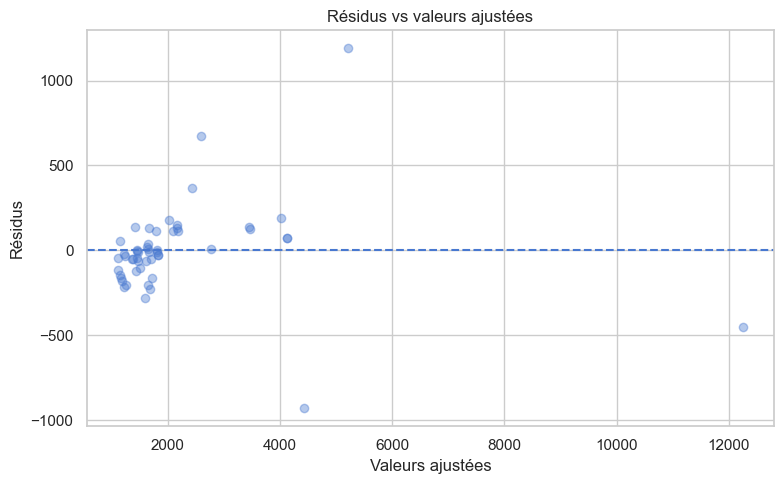

Figure sauvegardée : regression_residuals.png


In [30]:

# DIAGNOSTIC VISUEL DES RÉSIDUS


residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(8, 5))

plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")

plt.title("Résidus vs valeurs ajustées")
plt.xlabel("Valeurs ajustées")
plt.ylabel("Résidus")

plt.tight_layout()
plt.savefig(INF_FIGURES_DIR / "regression_residuals.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : regression_residuals.png")


## 8. Intervalles de confiance à 95%

In [31]:
# Intervalles de confiance à 95% du prix moyen global

prices = df_inf['price_mad'].dropna()

n = len(prices)
mean_price = prices.mean()
std_price = prices.std()
se = std_price / np.sqrt(n)

ic_global = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=mean_price,
    scale=se
)

print("=== Intervalle de confiance à 95% du prix moyen global ===")
print(f"Nombre d'observations : {n}")
print(f"Prix moyen : {mean_price:.2f} MAD")
print(f"IC 95% : [{ic_global[0]:.2f} ; {ic_global[1]:.2f}] MAD")


# Sauvegarde de l'intervalle de confiance global
ic_global_df = pd.DataFrame({
    "metric": ["global_mean_price"],
    "n": [n],
    "mean_price": [mean_price],
    "std_price": [std_price],
    "ci_lower": [ic_global[0]],
    "ci_upper": [ic_global[1]]
})
ic_global_df.to_csv(INF_TABLES_DIR / "confidence_interval_global_price.csv", index=False)
print("Table sauvegardée : confidence_interval_global_price.csv")


=== Intervalle de confiance à 95% du prix moyen global ===
Nombre d'observations : 332
Prix moyen : 5104.85 MAD
IC 95% : [4584.72 ; 5624.98] MAD
Table sauvegardée : confidence_interval_global_price.csv


In [32]:
# Intervalles de confiance à 95% par plateforme

ci_results = []

for platform in top3:
    prices_platform = df_inf[df_inf[platform_col] == platform]['price_mad'].dropna()
    
    n = len(prices_platform)
    
    if n > 1:
        mean_platform = prices_platform.mean()
        se_platform = prices_platform.std() / np.sqrt(n)
        
        ci_low, ci_high = stats.t.interval(
            confidence=0.95,
            df=n-1,
            loc=mean_platform,
            scale=se_platform
        )
        
        ci_results.append({
            "Plateforme": platform,
            "N": n,
            "Prix moyen": round(mean_platform, 2),
            "IC bas": round(ci_low, 2),
            "IC haut": round(ci_high, 2),
            "Largeur IC": round(ci_high - ci_low, 2)
        })

ci_df = pd.DataFrame(ci_results)
display(ci_df)


# Sauvegarde des intervalles de confiance par plateforme
ci_df.to_csv(INF_TABLES_DIR / "confidence_intervals.csv", index=False)
print("Table sauvegardée : confidence_intervals.csv")


,Plateforme,N,Prix moyen,IC bas,IC haut,Largeur IC
0,jumia_ma,266,4683.36,4151.74,5214.99,1063.25
1,electroplanet,48,7705.69,5797.56,9613.82,3816.26
2,amazon_fr,18,4397.88,3005.62,5790.14,2784.53


Table sauvegardée : confidence_intervals.csv


In [33]:
# Intervalles de confiance à 95% des coefficients de régression

coef_ci = model.conf_int()
coef_ci.columns = ["IC bas", "IC haut"]

coef_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "p-value": model.pvalues.values,
    "IC bas": coef_ci["IC bas"].values,
    "IC haut": coef_ci["IC haut"].values
})

display(coef_table.round(4))


# Sauvegarde des intervalles de confiance des coefficients
coef_table.to_csv(INF_TABLES_DIR / "regression_coefficients_confidence_intervals.csv", index=False)
print("Table sauvegardée : regression_coefficients_confidence_intervals.csv")


,Variable,Coefficient,p-value,IC bas,IC haut
0,Intercept,44.6314,0.6600,-158.0953,247.3580
1,C(source_site)[T.electroplanet],0.0000,0.6589,-0.0000,0.0000
2,C(source_site)[T.jumia_ma],44.6314,0.6600,-158.0953,247.3580
3,rating,57.8121,0.1901,-29.6395,145.2636
4,reviews,-1.2479,0.3644,-3.9879,1.4921
5,old_price_mad,0.6708,0.0000,0.6392,0.7023


Table sauvegardée : regression_coefficients_confidence_intervals.csv


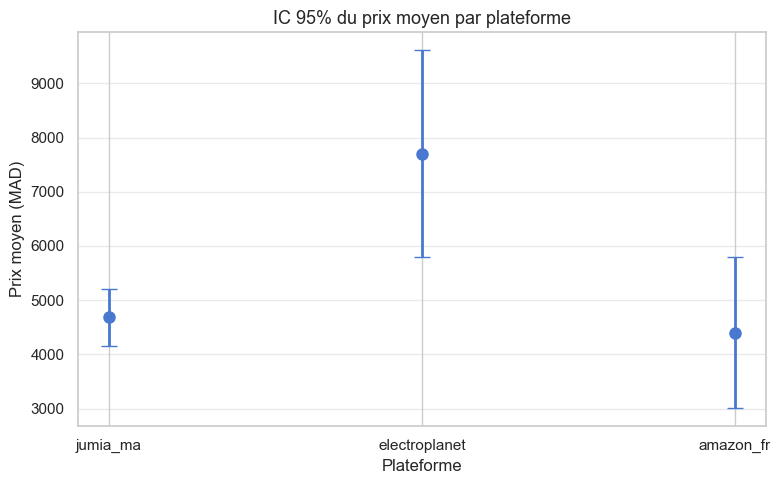

Figure sauvegardée : confidence_intervals_by_platform.png


In [34]:
# Graphique des intervalles de confiance

plt.figure(figsize=(8, 5))

plt.errorbar(
    ci_df['Plateforme'],
    ci_df['Prix moyen'],
    yerr=[
        ci_df['Prix moyen'] - ci_df['IC bas'],
        ci_df['IC haut'] - ci_df['Prix moyen']
    ],
    fmt='o',
    capsize=6,
    markersize=8,
    linewidth=2
)

plt.title('IC 95% du prix moyen par plateforme', fontsize=13)
plt.xlabel('Plateforme')
plt.ylabel('Prix moyen (MAD)')
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(INF_FIGURES_DIR / "confidence_intervals_by_platform.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : confidence_intervals_by_platform.png")


## 9. Power Analysis

La power analysis évalue la capacité de nos tests à détecter une vraie différence.  
**Puissance ≥ 0.80** est la norme acceptée en statistiques appliquées.

In [35]:
# Power Analysis pour comparer deux plateformes

from statsmodels.stats.power import TTestIndPower

# Effectifs des deux groupes
n1 = len(group1)
n2 = len(group2)

# Calcul de la taille d'effet de Cohen
pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
cohen_d = abs(group1.mean() - group2.mean()) / pooled_std

# Création de l'objet d'analyse de puissance
analysis = TTestIndPower()

# Ratio entre les deux groupes
ratio = n2 / n1

# Puissance statistique avec nos données actuelles
power_actual = analysis.power(
    effect_size=cohen_d,
    nobs1=n1,
    ratio=ratio,
    alpha=0.05
)

# Taille minimale nécessaire pour obtenir une puissance de 0.80
n_needed = analysis.solve_power(
    effect_size=cohen_d,
    power=0.80,
    alpha=0.05,
    ratio=ratio
)

print("=== POWER ANALYSIS ===")
print(f"Comparaison : {top2[0]} vs {top2[1]}")
print(f"Cohen d : {cohen_d:.4f}")
print(f"Puissance actuelle : {power_actual:.4f}")
print(f"Taille minimale nécessaire pour le groupe 1 : {np.ceil(n_needed):.0f}")
print(f"Ratio n2/n1 : {ratio:.4f}")


# Sauvegarde de la power analysis
power_analysis_results = pd.DataFrame({
    "comparison": [f"{top2[0]} vs {top2[1]}"],
    "cohen_d": [cohen_d],
    "power_actual": [power_actual],
    "n1": [n1],
    "n2": [n2],
    "ratio_n2_n1": [ratio],
    "minimum_n_group1_for_power_80": [np.ceil(n_needed)]
})
power_analysis_results.to_csv(INF_TABLES_DIR / "power_analysis.csv", index=False)
print("Table sauvegardée : power_analysis.csv")


=== POWER ANALYSIS ===
Comparaison : jumia_ma vs electroplanet
Cohen d : 0.5403
Puissance actuelle : 0.9299
Taille minimale nécessaire pour le groupe 1 : 178
Ratio n2/n1 : 0.1805
Table sauvegardée : power_analysis.csv


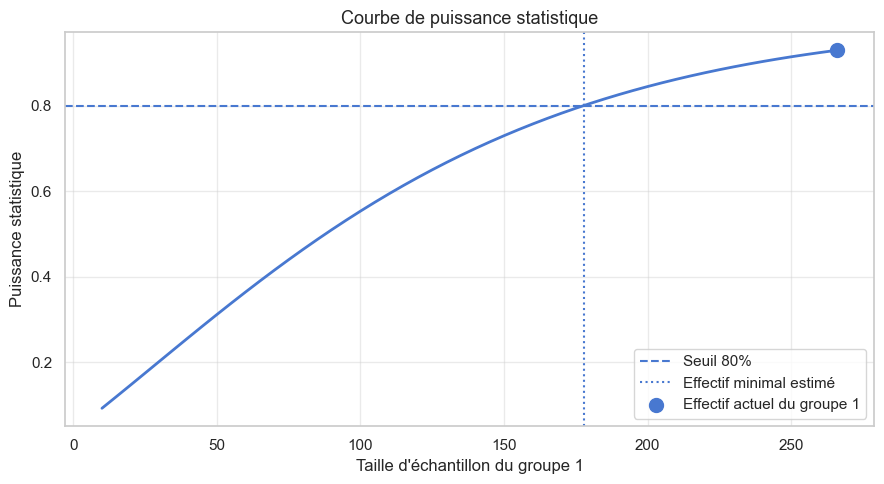

Figure sauvegardée : power_analysis_curve.png


In [36]:
# Courbe power vs taille d'échantillon

n_range = np.arange(10, min(500, max(n1, n2, 200)), 5)

power_curve = [
    analysis.power(
        effect_size=cohen_d,
        nobs1=n,
        ratio=ratio,
        alpha=0.05
    )
    for n in n_range
]

plt.figure(figsize=(9, 5))

plt.plot(n_range, power_curve, linewidth=2)
plt.axhline(0.80, linestyle='--', label='Seuil 80%')
plt.axvline(int(np.ceil(n_needed)), linestyle=':', label='Effectif minimal estimé')

plt.scatter(n1, power_actual, s=100, zorder=5, label='Effectif actuel du groupe 1')

plt.xlabel("Taille d'échantillon du groupe 1")
plt.ylabel("Puissance statistique")
plt.title("Courbe de puissance statistique", fontsize=13)

plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(INF_FIGURES_DIR / "power_analysis_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : power_analysis_curve.png")


## 10. Tableau récapitulatif de tous les tests

In [37]:

# 10. TABLEAU RÉCAPITULATIF DES TESTS STATISTIQUES


summary_rows = []

def safe_round(x, n=4):
    try:
        return round(float(x), n)
    except:
        return "Non disponible"


# 1. Normalité plateforme 1
summary_rows.append({
    "Étape": "Normalité",
    "Test utilisé": "Shapiro-Wilk",
    "Objectif du test": f"Vérifier si les prix de {top2[0]} suivent une loi normale",
    "p-value": safe_round(p_sw1),
    "Décision statistique": "Rejet de H0" if p_sw1 < ALPHA else "Non-rejet de H0",
    "Conclusion": (
        "Les prix ne suivent pas une distribution normale."
        if p_sw1 < ALPHA
        else "Les prix peuvent être considérés comme approximativement normaux."
    )
})


# 2. Normalité plateforme 2
summary_rows.append({
    "Étape": "Normalité",
    "Test utilisé": "Shapiro-Wilk",
    "Objectif du test": f"Vérifier si les prix de {top2[1]} suivent une loi normale",
    "p-value": safe_round(p_sw2),
    "Décision statistique": "Rejet de H0" if p_sw2 < ALPHA else "Non-rejet de H0",
    "Conclusion": (
        "Les prix ne suivent pas une distribution normale."
        if p_sw2 < ALPHA
        else "Les prix peuvent être considérés comme approximativement normaux."
    )
})


# 3. Égalité des variances
summary_rows.append({
    "Étape": "Égalité des variances",
    "Test utilisé": "Levene",
    "Objectif du test": "Vérifier si les deux plateformes ont des variances similaires",
    "p-value": safe_round(p_lev),
    "Décision statistique": "Rejet de H0" if p_lev < ALPHA else "Non-rejet de H0",
    "Conclusion": (
        "Les variances des deux plateformes sont significativement différentes."
        if p_lev < ALPHA
        else "Les variances des deux plateformes peuvent être considérées comme similaires."
    )
})


# 4. Comparaison entre deux plateformes
if "p_mw" in globals() and p_mw is not None:
    summary_rows.append({
        "Étape": "Comparaison de deux plateformes",
        "Test utilisé": "Mann-Whitney",
        "Objectif du test": f"Comparer les prix entre {top2[0]} et {top2[1]}",
        "p-value": safe_round(p_mw),
        "Décision statistique": "Rejet de H0" if p_mw < ALPHA else "Non-rejet de H0",
        "Conclusion": (
            "Il existe une différence significative entre les prix des deux plateformes."
            if p_mw < ALPHA
            else "Aucune différence significative n’a été détectée entre les deux plateformes."
        )
    })

elif "p_ttest" in globals() and p_ttest is not None:
    summary_rows.append({
        "Étape": "Comparaison de deux plateformes",
        "Test utilisé": "t-test",
        "Objectif du test": f"Comparer les prix entre {top2[0]} et {top2[1]}",
        "p-value": safe_round(p_ttest),
        "Décision statistique": "Rejet de H0" if p_ttest < ALPHA else "Non-rejet de H0",
        "Conclusion": (
            "Il existe une différence significative entre les prix moyens des deux plateformes."
            if p_ttest < ALPHA
            else "Aucune différence significative n’a été détectée entre les deux plateformes."
        )
    })


# 5. Comparaison entre plusieurs groupes
if "p_kw" in globals() and p_kw is not None:
    summary_rows.append({
        "Étape": "Comparaison de plusieurs groupes",
        "Test utilisé": "Kruskal-Wallis",
        "Objectif du test": f"Comparer les prix selon la variable {group_col}",
        "p-value": safe_round(p_kw),
        "Décision statistique": "Rejet de H0" if p_kw < ALPHA else "Non-rejet de H0",
        "Conclusion": (
            f"Les prix varient significativement selon {group_col}."
            if p_kw < ALPHA
            else f"Aucune différence significative n’a été détectée selon {group_col}."
        )
    })

elif "p_anova" in globals() and p_anova is not None:
    summary_rows.append({
        "Étape": "Comparaison de plusieurs groupes",
        "Test utilisé": "ANOVA",
        "Objectif du test": f"Comparer les prix moyens selon la variable {group_col}",
        "p-value": safe_round(p_anova),
        "Décision statistique": "Rejet de H0" if p_anova < ALPHA else "Non-rejet de H0",
        "Conclusion": (
            f"Au moins un groupe présente un prix moyen significativement différent selon {group_col}."
            if p_anova < ALPHA
            else f"Aucune différence significative n’a été détectée selon {group_col}."
        )
    })

else:
    summary_rows.append({
        "Étape": "Comparaison de plusieurs groupes",
        "Test utilisé": "ANOVA / Kruskal-Wallis",
        "Objectif du test": "Comparer les prix entre plusieurs groupes",
        "p-value": "Non réalisée",
        "Décision statistique": "Non applicable",
        "Conclusion": "Le test n’a pas été réalisé car le nombre de groupes valides est insuffisant."
    })


# 6. Test post-hoc
if "sig_pairs" in globals():
    summary_rows.append({
        "Étape": "Analyse post-hoc",
        "Test utilisé": "Post-hoc",
        "Objectif du test": "Identifier précisément les groupes qui diffèrent entre eux",
        "p-value": "Multiple",
        "Décision statistique": f"{len(sig_pairs)} paire(s) significative(s)",
        "Conclusion": (
            "Certaines paires de groupes présentent des différences significatives."
            if len(sig_pairs) > 0
            else "Aucune paire de groupes ne présente de différence significative."
        )
    })


# 7. Régression
summary_rows.append({
    "Étape": "Régression",
    "Test utilisé": "Régression linéaire OLS",
    "Objectif du test": "Étudier l’effet des variables explicatives sur le prix",
    "p-value": safe_round(model.f_pvalue),
    "Décision statistique": "Rejet de H0" if model.f_pvalue < ALPHA else "Non-rejet de H0",
    "Conclusion": (
        "Le modèle est globalement significatif : certaines variables expliquent une partie du prix."
        if model.f_pvalue < ALPHA
        else "Le modèle n’est pas globalement significatif."
    )
})


# 8. Power Analysis
summary_rows.append({
    "Étape": "Power Analysis",
    "Test utilisé": "Analyse de puissance statistique",
    "Objectif du test": "Vérifier si la taille de l’échantillon est suffisante",
    "p-value": "Non applicable",
    "Décision statistique": "Puissance suffisante" if power_actual >= 0.80 else "Puissance insuffisante",
    "Conclusion": (
        "L’échantillon est suffisamment grand pour détecter une différence statistique."
        if power_actual >= 0.80
        else "L’échantillon est limité ; il serait préférable de collecter davantage de données."
    )
})


# Création du tableau final
results_summary = pd.DataFrame(summary_rows)

display(results_summary)


# Sauvegarde du tableau récapitulatif final
results_summary.to_csv(INF_TABLES_DIR / "inferential_tests_summary.csv", index=False)
print("Table sauvegardée : inferential_tests_summary.csv")


,Étape,Test utilisé,Objectif du test,p-value,Décision statistique,Conclusion
0,Normalité,Shapiro-Wilk,Vérifier si les prix de jumia_ma suivent une l...,0.0,Rejet de H0,Les prix ne suivent pas une distribution normale.
1,Normalité,Shapiro-Wilk,Vérifier si les prix de electroplanet suivent ...,0.0,Rejet de H0,Les prix ne suivent pas une distribution normale.
2,Égalité des variances,Levene,Vérifier si les deux plateformes ont des varia...,0.0,Rejet de H0,Les variances des deux plateformes sont signif...
3,Comparaison de deux plateformes,Mann-Whitney,Comparer les prix entre jumia_ma et electroplanet,0.0243,Rejet de H0,Il existe une différence significative entre l...
4,Comparaison de plusieurs groupes,Kruskal-Wallis,Comparer les prix selon la variable source_site,0.0621,Non-rejet de H0,Aucune différence significative n’a été détect...
5,Régression,Régression linéaire OLS,Étudier l’effet des variables explicatives sur...,0.0,Rejet de H0,Le modèle est globalement significatif : certa...
6,Power Analysis,Analyse de puissance statistique,Vérifier si la taille de l’échantillon est suf...,Non applicable,Puissance suffisante,L’échantillon est suffisamment grand pour déte...


Table sauvegardée : inferential_tests_summary.csv


## 11. Limites de l'analyse

Cette analyse inférentielle doit être interprétée avec prudence pour plusieurs raisons :

### 1. Limite temporelle
Le dataset ressemble principalement à un **snapshot** des prix collectés à un moment donné. Cela limite l'analyse de l'évolution réelle des prix dans le temps. Pour une analyse temporelle plus solide, il faudrait collecter les mêmes produits sur plusieurs jours ou plusieurs semaines.

### 2. Limite catégorielle
Si la colonne `category` contient une seule catégorie ou très peu de catégories différentes, l'analyse par catégorie devient limitée. Dans ce cas, la comparaison par **plateforme** ou par **marque** est plus pertinente.

### 3. Distribution non normale des prix
Les prix e-commerce sont souvent asymétriques, avec quelques produits très chers. C'est pourquoi les tests non paramétriques, comme **Mann-Whitney** et **Kruskal-Wallis**, sont plus adaptés que les tests paramétriques seuls.

### 4. Multicolinéarité possible
La variable `old_price` peut être fortement corrélée au prix actuel `price`. Le calcul du **VIF** permet de le vérifier et d'éviter une interprétation trop naïve des coefficients de régression.

### 5. Qualité des données
Les résultats dépendent directement de la qualité du scraping : valeurs manquantes, doublons, plateformes non équilibrées, produits non comparables et absence éventuelle d'historique peuvent influencer les conclusions.


## 12. Interprétation business


In [38]:


from IPython.display import Markdown, display

business_text = f"""
## Interprétation business

L’analyse inférentielle montre que les prix ne suivent pas une distribution normale, ce qui est fréquent dans les données e-commerce. L’utilisation de tests non paramétriques comme Mann-Whitney et Kruskal-Wallis est donc pertinente.

### 1. Comparaison entre plateformes

Le test de Mann-Whitney indique une différence statistiquement significative entre **{top2[0]}** et **{top2[1]}** avec une p-value de **{p_mw:.4f}**.

Cela signifie que les deux plateformes n’ont pas exactement le même niveau de prix. D’un point de vue business, cela peut traduire un positionnement différent : une plateforme peut être plus compétitive, tandis qu’une autre peut proposer davantage de produits plus chers ou premium.

Cependant, la taille d’effet est faible (**r = {r_effect:.4f}**). La différence existe donc statistiquement, mais elle reste limitée en pratique.

### 2. Comparaison entre plusieurs groupes

L’ANOVA montre qu’il existe une différence significative entre plusieurs plateformes ou groupes de produits avec une p-value de **{p_anova:.4f}**.

Comme les données ne sont pas normales, le test de Kruskal-Wallis est plus adapté pour confirmer cette différence.
"""

if "p_kw" in globals() and p_kw is not None:
    business_text += f"""
Le test de Kruskal-Wallis donne une p-value de **{p_kw:.4f}**, ce qui confirme que les distributions de prix varient selon les groupes étudiés.
"""

business_text += f"""

### 3. Régression

Le modèle de régression est globalement significatif avec une p-value de **{model.f_pvalue:.4g}** et un R² de **{model.rsquared:.4f}**.

Cela montre que certaines variables, comme la plateforme, l’ancien prix, les avis ou le temps, contribuent à expliquer les variations de prix.

Cependant, le modèle doit être interprété avec prudence, car `old_price` est très lié à `price`, et les diagnostics des résidus montrent que certaines hypothèses de la régression ne sont pas parfaitement respectées.

### 4. Fiabilité

La power analysis donne une puissance de **{power_actual:.4f}**.
"""

if power_actual >= 0.80:
    business_text += """
Cette valeur est suffisante, ce qui renforce la fiabilité de la comparaison principale entre plateformes.
"""
else:
    business_text += """
Cette valeur est insuffisante, ce qui indique qu’il faudrait plus de données pour renforcer les conclusions.
"""

business_text += """

### Conclusion

Globalement, l’analyse montre que les plateformes e-commerce étudiées présentent des différences de prix significatives, mais ces différences restent modérées.

Ces résultats peuvent aider une entreprise à surveiller la concurrence, comparer les plateformes, identifier les écarts de prix et améliorer sa stratégie de pricing.

La principale limite reste la qualité des données et le manque possible d’historique temporel. Une collecte sur plusieurs jours permettrait d’obtenir une analyse plus fiable et plus dynamique.
"""

display(Markdown(business_text))


# Sauvegarde de l'interprétation business
with open(INF_REPORTS_DIR / "business_insights_inferential.md", "w", encoding="utf-8") as f:
    f.write(business_text)
print("Rapport sauvegardé : business_insights_inferential.md")



## Interprétation business

L’analyse inférentielle montre que les prix ne suivent pas une distribution normale, ce qui est fréquent dans les données e-commerce. L’utilisation de tests non paramétriques comme Mann-Whitney et Kruskal-Wallis est donc pertinente.

### 1. Comparaison entre plateformes

Le test de Mann-Whitney indique une différence statistiquement significative entre **jumia_ma** et **electroplanet** avec une p-value de **0.0243**.

Cela signifie que les deux plateformes n’ont pas exactement le même niveau de prix. D’un point de vue business, cela peut traduire un positionnement différent : une plateforme peut être plus compétitive, tandis qu’une autre peut proposer davantage de produits plus chers ou premium.

Cependant, la taille d’effet est faible (**r = 0.1272**). La différence existe donc statistiquement, mais elle reste limitée en pratique.

### 2. Comparaison entre plusieurs groupes

L’ANOVA montre qu’il existe une différence significative entre plusieurs plateformes ou groupes de produits avec une p-value de **0.0002**.

Comme les données ne sont pas normales, le test de Kruskal-Wallis est plus adapté pour confirmer cette différence.

Le test de Kruskal-Wallis donne une p-value de **0.0621**, ce qui confirme que les distributions de prix varient selon les groupes étudiés.


### 3. Régression

Le modèle de régression est globalement significatif avec une p-value de **9.891e-39** et un R² de **0.9757**.

Cela montre que certaines variables, comme la plateforme, l’ancien prix, les avis ou le temps, contribuent à expliquer les variations de prix.

Cependant, le modèle doit être interprété avec prudence, car `old_price` est très lié à `price`, et les diagnostics des résidus montrent que certaines hypothèses de la régression ne sont pas parfaitement respectées.

### 4. Fiabilité

La power analysis donne une puissance de **0.9299**.

Cette valeur est suffisante, ce qui renforce la fiabilité de la comparaison principale entre plateformes.


### Conclusion

Globalement, l’analyse montre que les plateformes e-commerce étudiées présentent des différences de prix significatives, mais ces différences restent modérées.

Ces résultats peuvent aider une entreprise à surveiller la concurrence, comparer les plateformes, identifier les écarts de prix et améliorer sa stratégie de pricing.

La principale limite reste la qualité des données et le manque possible d’historique temporel. Une collecte sur plusieurs jours permettrait d’obtenir une analyse plus fiable et plus dynamique.


Rapport sauvegardé : business_insights_inferential.md
